# De Pesos Aleatorios a un Modelo Funcional: El Proceso de Preentrenamiento (Pre-training)

Hasta ahora, la arquitectura del Transformer que implementamos es solo un esqueleto: una serie de operaciones matriciales con **pesos inicializados aleatoriamente**. Sin entrenamiento, este modelo solo genera ruido estadístico.

El **preentrenamiento (*pre-training*)** es la fase donde esos números aleatorios se ajustan para capturar la estructura gramatical, semántica y fáctica del lenguaje. En el fondo, **la mecánica no es diferente a la de cualquier otra red neuronal profunda**: utiliza *Backpropagation*, optimizadores basados en gradiente descendente (como AdamW), funciones de pérdida estándar (Cross-Entropy Loss) y técnicas de regularización (*Dropout*, *Weight Decay*). Lo que cambia radicalmente es la **escala de los datos y el objetivo de optimización**.

---

## Las 3 Fases del Entrenamiento de un LLM: Pre-training vs. Fine-tuning vs. Instruction Tuning

Para entender el ciclo de vida de un modelo de lenguaje, es fundamental diferenciar sus etapas:

| Criterio | 1. Pre-training (Preentrenamiento) | 2. Fine-tuning Clásico | 3. Instruction Tuning (Alineación / SFT) |
| :--- | :--- | :--- | :--- |
| **Propósito** | Aprender la estructura general del lenguaje, patrones del mundo y predicción del siguiente token (*Next-Token Prediction*). | Adaptar un modelo ya preentrenado a una tarea especializada única (ej. análisis de sentimiento, clasificación de texto médico). | Convertir un completador de texto estadístico en un **asistente conversacional** capaz de seguir instrucciones y responder preguntas. |
| **Datos (*Data*)** | **Terabytes o Petabytes** de texto crudo sin etiquetar (libros, artículos, código, Wikipedia, Common Crawl). Autosupervisado. | Miles a decenas de miles de pares específicos etiquetados: `(texto_entrada, etiqueta_objetivo)`. | Decenas de miles de pares estructurados: `(Prompt / Instrucción, Respuesta ideal)`. |
| **Entrenamiento** | Cómputo masivo: miles de GPUs durante semanas o meses. Ajuste de **todos los pesos** desde cero. | Cómputo bajo/medio (horas en pocas GPUs). Puede ajustar todas las capas o usar métodos eficientes como **LoRA / QLoRA**. | Cómputo medio. Entrenamiento supervisado (*Supervised Fine-Tuning - SFT*) seguido habitualmente de alineación por preferencias (RLHF / DPO). |
| **Aplicaciones** | Base fundacional sobre la cual se construyen todos los demás modelos (ej. GPT base, LLaMA base). | Modelos especializados de producción para tareas concretas y de baja latencia. | Chatbots, asistentes de código, agentes autónomos y herramientas de razonamiento. |

---

## ¿Por qué casi nadie debe preentrenar un LLM desde cero?

En la industria y la investigación aplicada, **preentrenar un modelo base desde cero prácticamente nunca es la decisión correcta** para la gran mayoría de equipos o empresas:

1. **Barrera de Cómputo y Costes:** Preentrenar un modelo competitivo de tamaño medio (ej. 7B–8B parámetros) requiere clústeres de cientos de GPUs de gama alta (H100/A100) y millones de dólares en infraestructura de nube y energía.
2. **Ingeniería de Datos:** La mayor dificultad no es el código de PyTorch, sino recolectar, filtrar, desduplicar y limpiar billones de tokens de datos de alta calidad.
3. **Disponibilidad de Modelos Abiertos (*Open Weights*):** Con la disponibilidad de pesos abiertos de primer nivel (LLaMA, Mistral, Qwen, Gemma), el estándar de la industria consiste en **partir de un modelo ya preentrenado** y aplicar **Fine-Tuning / LoRA** o **RAG (Retrieval-Augmented Generation)** adaptado a los datos del dominio específico.

In [ ]:
# Un modelo en el Pre entrenamiento no puede hacer mucho - Fine tunning para tareas especificas - Instruction tunning Usabilidad

# El Ciclo de Datos y Entrenamiento en LLMs: Pre-training vs. Fine-Tuning vs. Instruction Tuning

Construir y adaptar un modelo de lenguaje no es solo una cuestión de código; la clave reside en **la naturaleza de los datos, el método de supervisión y el coste computacional** de cada fase.

---

## 1. El Desafío de los Datos: ¿Cómo se alimenta cada etapa?

### Pre-training (Preentrenamiento Fundacional)
* **Volumen masivo:** Requiere más texto del que toda la humanidad podría leer en varias vidas (billones de tokens).
* **El problema de la calidad:** Alimentar un modelo con «todo el internet» no es trivial: la mayor parte del texto web es ruidosa, repetitiva, de baja calidad o directamente tóxica. Limpiarla, filtrarla, desduplicarla y abordar las implicaciones legales y de derechos de autor representa el mayor esfuerzo del proceso.
* **Naturaleza:** Datos crudos no estructurados (código, libros, páginas web, artículos).

### Fine-Tuning (Alineación de Dominio o Tarea)
* **Datos curados y específicos:** No necesita todo internet; utiliza un conjunto de datos mucho más reducido y seleccionado para convertir al modelo en un experto en un dominio concreto (por ejemplo, la documentación técnica interna de una empresa, repositorios de código privados, correos o historiales de tickets).
* **Naturaleza:** Documentos técnicos, pares de clasificación o textos estructurados del nicho objetivo.

### Instruction Tuning (Alineación Conversacional / SFT)
* **Pares de interacción humana:** Se construye a partir de miles de indicaciones (*prompts*) y respuestas ideales redactadas o curadas por humanos expertos.
* **Naturaleza:** Conversaciones estructuradas `[Instrucción / Pregunta → Respuesta deseada]` que enseñan al modelo a comportarse como un asistente útil y seguro.

---

## 2. Supervisión, Tiempos y Recursos de Cómputo

| Fase | Nivel de Supervisión | Tiempo y Cómputo | ¿Dónde se ejecuta? |
| :--- | :--- | :--- | :--- |
| **Pre-training** | **Autosupervisado** (sin intervención humana directa). El modelo simplemente minimiza el error al predecir el siguiente token (*Next-Token Prediction*). | **Meses de cómputo** continuo y millones de dólares en energía e infraestructura. | Imposible en una laptop; exige clústeres masivos de cientos o miles de GPUs (H100/A100). |
| **Fine-Tuning** | **Supervisado / Adaptativo**. Ajusta pesos sobre una tarea o distribución cerrada de datos. | De **pocas horas a días o semanas**, dependiendo del tamaño del dataset y si se usan técnicas eficientes (LoRA/QLoRA). | Servidores dedicados o instancias de GPU individuales en la nube. |
| **Instruction Tuning** | **Supervisado (SFT)**. El cuello de botella está en crear el dataset humano, pero el entrenamiento computacional es muy ágil. | El entrenamiento real suele tomar de **horas a un par de días**. | Estaciones de trabajo con GPUs potentes o instancias individuales en la nube. |

---

## 3. ¿Para qué se utiliza cada modelo en el mundo real?

* **Modelos Pre-trained Base:**  
  Son la base fundacional. En la industria se utilizan como punto de partida para entrenar otros modelos, y en la investigación académica son el objeto principal de estudio para la **interpretabilidad mecanicista**, el análisis de representaciones internas y la comprensión de circuitos neuronales.
* **Modelos con Fine-Tuning:**  
  Diseñados para ejecutar tareas analíticas o de negocio cerradas con alta precisión: clasificar reseñas de productos (positivas/negativas), resumir contratos legales, extraer entidades de historias clínicas o consultar bases de conocimiento propietarias.
* **Modelos con Instruction Tuning:**  
  Es la capa visible y comercialmente más extendida. Es la tecnología detrás de asistentes conversacionales (ChatGPT, Claude), agentes autónomos de servicio al cliente, copilotos de código o asistentes de gestión y generación de contenido.


In [ ]:
# Antes del entrenamiento el modelo es llamado Base Model (Modelo Base)

In [ ]:
# Cuesta millones de dolares y  lleva meses de calculo, trabajando en procesamiento en clusters de miles de GPUS conectadas en red y operadas por un equipo

## Optimización y Algoritmos Basados en Gradiente

Un concepto fundamental en el entrenamiento de redes neuronales y Transformers es cómo actualizamos los parámetros ($\theta$) para minimizar la función de pérdida ($\mathcal{L}$).

---

### 1. El Fundamento: Media Ponderada Exponencialmente (EWMA)

La **EWMA (Exponentially Weighted Moving Average)** o media móvil exponencial es una técnica estadística utilizada para suavizar secuencias temporales dando mayor peso a las observaciones recientes y reduciendo exponencialmente la influencia de las pasadas:

$$v_t = \beta v_{t-1} + (1 - \beta) g_t$$

Donde $\beta \in [0, 1)$ es el factor de decaimiento y $g_t = \nabla_\theta \mathcal{L}$ es el gradiente en el paso $t$. Esta formulación es la base matemática de los optimizadores modernos con inercia y tasas de aprendizaje adaptativas.

---

### 2. Estrategias de Muestreo de Datos

* **Batch Gradient Descent:** Calcula el gradiente utilizando **todo el conjunto de datos** en cada iteración:
  $$\theta_{t+1} = \theta_t - \eta \cdot \frac{1}{N} \sum_{i=1}^N \nabla_\theta \mathcal{L}(x_i, y_i; \theta_t)$$
  *Garantiza convergencia suave, pero es intratable en memoria VRAM para datasets grandes.*

* **Stochastic Gradient Descent (SGD puro):** Actualiza los parámetros utilizando **un único ejemplo** ($N = 1$) en cada paso:
  $$\theta_{t+1} = \theta_t - \eta \cdot \nabla_\theta \mathcal{L}(x_t, y_t; \theta_t)$$
  *Es computacionalmente ligero, pero introduce una varianza y ruido excesivos en las actualizaciones.*

* **Mini-batch Gradient Descent:** Procesa un subconjunto de tamaño $B$ (por ejemplo, 32, 64 o 128 muestras) en cada paso:
  $$\theta_{t+1} = \theta_t - \eta \cdot \frac{1}{B} \sum_{i=1}^B \nabla_\theta \mathcal{L}(x_i, y_i; \theta_t)$$
  *Aprovecha la paralelización matricial en GPUs y equilibra velocidad, estabilidad y uso de memoria.*

---

### 3. Familia de Optimizadores Avanzados

#### A. Momentum (SGD con Inercia)
Aplica **EWMA sobre el primer momento** (la dirección del gradiente) para amortiguar oscilaciones en direcciones de alta curvatura y acelerar en mesetas:
$$v_t = \beta v_{t-1} + \eta g_t$$
$$\theta_{t+1} = \theta_t - v_t$$

---

#### B. RMSprop (Root Mean Square Propagation)
Aplica **EWMA sobre el segundo momento no centrado** (el gradiente al cuadrado), adaptando la tasa de aprendizaje de forma individual para cada parámetro:
$$s_t = \beta s_{t-1} + (1 - \beta) g_t^2$$
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{s_t} + \epsilon} \odot g_t$$

*Divide la actualización entre la raíz de la media cuadrática, desacelerando parámetros con gradientes gigantes y acelerando aquellos con gradientes pequeños.*

---

#### C. Adam (Adaptive Moment Estimation)
Combina las ventajas de **Momentum** (primer momento $m_t$) y **RMSprop** (segundo momento $v_t$), incorporando un **término de corrección de sesgo (*bias correction*)** para compensar la inicialización de los vectores en cero en los primeros pasos:

1. **Primer momento (dirección con inercia):**
   $$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$

2. **Segundo momento (magnitud al cuadrado):**
   $$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$

3. **Corrección de sesgo:**
   $$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

4. **Actualización de parámetros:**
   $$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \odot \hat{m}_t$$

*(Valores hiperparamétricos estándar: $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$).*

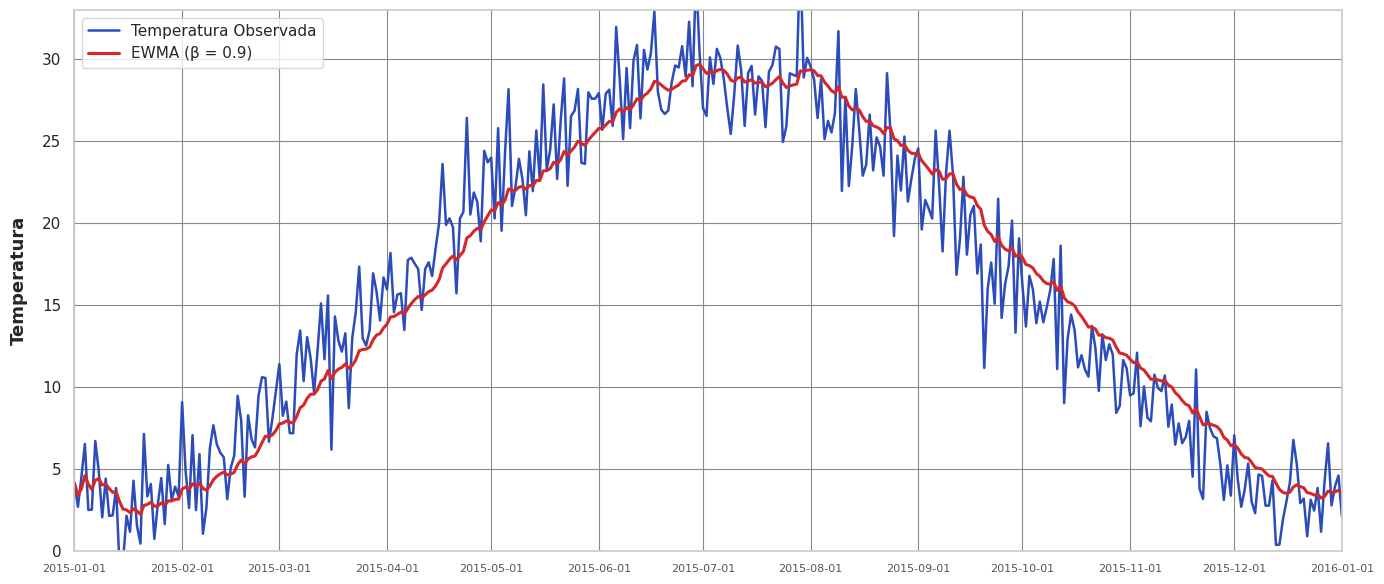

In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

# 2. Generación de datos sintéticos representativos del año 2015
np.random.seed(42)
dates = pd.date_range(start="2015-01-01", end="2016-01-01", freq="D")
n = len(dates)

# Simulación de la curva de temperatura anual + componente de ruido
t = np.linspace(0, 2 * np.pi, n)
seasonal_trend = 16 - 13 * np.cos(t)  # Mínimo ~3°C en invierno, pico ~29°C en verano
noise = np.random.normal(0, 2.3, n)
temperature = seasonal_trend + noise

df = pd.DataFrame({"Fecha": dates, "Temperatura": temperature})

# 3. Cálculo de EWMA con Bias Correction (β = 0.9)
beta = 0.9
v_raw = np.zeros(n)
v_corrected = np.zeros(n)
v_prev = 0.0

for i, val in enumerate(df["Temperatura"].values, start=1):
  v_t = beta * v_prev + (1 - beta) * val
  v_raw[i - 1] = v_t
  v_corrected[i - 1] = v_t / (1 - (beta**i))
  v_prev = v_t

df["EWMA_Corrected"] = v_corrected

# 4. Construcción del gráfico con Seaborn
fig, ax = plt.subplots(figsize=(14, 6))

# Serie original (azul)
sns.lineplot(
    data=df,
    x="Fecha",
    y="Temperatura",
    color="#2b4cba",
    linewidth=1.8,
    ax=ax,
    label="Temperatura Observada",
)

# Línea suavizada EWMA con Bias Correction (roja)
sns.lineplot(
    data=df,
    x="Fecha",
    y="EWMA_Corrected",
    color="#d62728",
    linewidth=2.2,
    ax=ax,
    label=f"EWMA (β = {beta})",
)

# 5. Ajustes idénticos a los ejes y ticks de la imagen
ax.set_ylabel("Temperatura", fontsize=13, fontweight="bold", labelpad=10)
ax.set_xlabel("", visible=False)
ax.set_ylim(0, 33)
ax.set_xlim(pd.Timestamp("2015-01-01"), pd.Timestamp("2016-01-01"))

# Formateo mensual de fechas en el eje X (YYYY-MM-DD)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.setp(
    ax.get_xticklabels(), rotation=0, ha="center", fontsize=8, color="#555555"
)

# Configuración de grilla
ax.grid(True, which="major", color="#888888", linestyle="-", linewidth=0.8)
ax.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

Aquí tienes el desglose directo y simplificado fórmula por fórmula:

* **SGD:** Gradiente simple paso a paso (1 sola muestra).
* **Mini-batch GD:** Gradiente promedio por lote pequeño de muestras.
* **Momentum:** Mini-batch + **EWMA de los gradientes** (1er momento / inercia).
* **RMSprop:** Mini-batch + **EWMA de los gradientes al cuadrado** (2do momento / tasa adaptativa).
* **Adam:** Mini-batch + **Momentum** (1er momento) + **RMSprop** (2do momento) + **Bias Correction**.
* **AdamW:** **Adam** + **Weight Decay desacoplado** (aplicado directamente a los pesos, no al gradiente).

# Otros saltos en el gradiente

* **Polyak Momentum (Momentum Clásico):** Mini-batch + **EWMA de gradientes pasados** $\to$ Calcula el gradiente en la posición actual y le suma el vector de velocidad acumulado.
* **Nesterov Accelerated Gradient (NAG):** Mini-batch + **Look-ahead step** + **EWMA** $\to$ Da primero un "salto hacia adelante" en la dirección de la inercia acumulada, evalúa el gradiente en esa posición futura estimada y luego aplica la corrección.
* **NAdam:** **Adam** + **Nesterov Momentum** $\to$ Combina RMSprop (2do momento adaptativo) + Nesterov (1er momento con anticipación) + Bias Correction.

In [2]:
# Los modelos de LLMs usan Adamw